In [2]:
import numpy as np
import pandas as pd 
import os
import cv2
import matplotlib.pyplot as plt

# Use a transfer-learning friendly resolution for MobileNetV2.
IMG_SIZE = 160

In [2]:
labels = os.listdir("train")
labels

['Closed', 'no_yawn', 'Open', 'yawn']

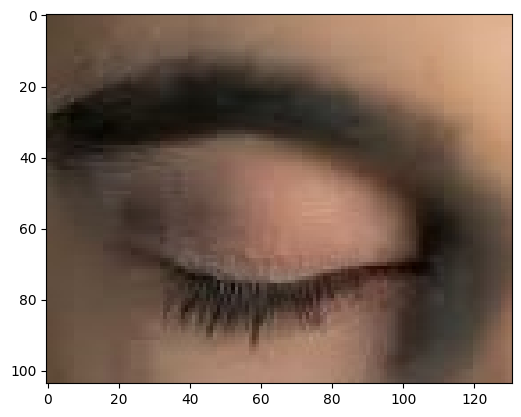

In [3]:
plt.imshow(plt.imread("train/Closed/_26.jpg"))

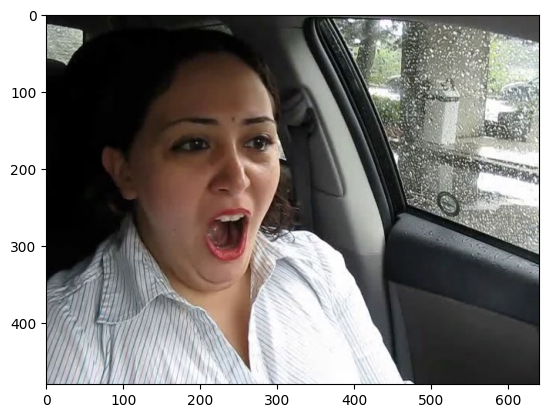

In [4]:
plt.imshow(plt.imread("train/yawn/109.jpg"))  # display the first image in the yawn_no_yawn list

## Preprocessing Images
### Yawning Dataset: Resizing + Crop Faces + Yawning Label

In [5]:
def face_for_yawn(direc="train", face_cas_path=cv2.data.haarcascades + "haarcascade_frontalface_default.xml"):
    yaw_no = []  # create an empty list to store .image arrays and their respective class numbers
    categories = ["yawn", "no_yawn"]  # define the categories of the images
    face_cascade = cv2.CascadeClassifier(face_cas_path)  # load face detector once
    for category in categories:
        path_link = os.path.join(direc, category)  # create a path to the directory of each category
        class_num1 = categories.index(category)  # assign a unique class number to each category
        print(class_num1)  # print the class number for debugging purposes
        for image in os.listdir(path_link):  # loop through all the images in the directory
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)  # read the image and store it as an array
            if image_array is None:
                continue
            faces = face_cascade.detectMultiScale(image_array, 1.3, 5)  # detect all faces in the image
            if len(faces) == 0:
                # Fall back to the whole image when no face is detected.
                resized_array = cv2.resize(image_array, (IMG_SIZE, IMG_SIZE))
                yaw_no.append([resized_array, class_num1])
            for (x, y, w, h) in faces:  # loop through all the detected faces
                roi_color = image_array[y:y+h, x:x+w]  # crop the image to only include the face
                resized_array = cv2.resize(roi_color, (IMG_SIZE, IMG_SIZE))  # resize the cropped image to the desired size
                yaw_no.append([resized_array, class_num1])  # add the resized image and its class number to the list
    return yaw_no  # return the list of resized images and their class numbers


yawn_no_yawn = face_for_yawn()  # call the face_for_yawn function and store the result in yawn_no_yawn variable

0
1


### Eyes Dataset: Resizing Images + Eyes Label

In [6]:
# This function is getting data from a directory
# It is resizing the images to a specified size and appending the resized image and its label to a list
# The function returns the list of data
def get_data(dir_path="train/"):
    # Define the labels for the data
    labels = ['Closed', 'Open']
    # Create an empty list to store the data
    data = []
    # Loop through each label in the labels list
    for label in labels:
        # Define the path to the label's directory
        path = os.path.join(dir_path, label)
        # Get the index of the label in the labels list
        class_num = labels.index(label)
        # Add 2 to the class number to account for the additional classes for face and eyes
        class_num += 2
        # Loop through each image in the label's directory
        for img in os.listdir(path):
            try:
                # Read in the image and resize it
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                if img_array is None:
                    continue
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                # Append the resized image and its label to the data list
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    # Return the list of data
    return data
data_train = get_data()

In [7]:
data_train[0][0].shape

(160, 160, 3)

### Preprocessed Data Combination

In [8]:
def append_data():
    # call the `face_for_yawn()` function to get yawning and non-yawning face images
    yaw_no = face_for_yawn()
    
    # call the `get_data()` function to get open and closed eye images
    data = get_data()
    
    # combine the two datasets into a single list using the `extend()` method
    yaw_no.extend(data)
    
    # convert the resulting list to a NumPy array and return it
    return np.array(yaw_no)

new_data = append_data()

0
1


C:\Users\danie\AppData\Local\Temp\ipykernel_48612\3699675822.py:12: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(yaw_no)


### Transforming Appended Dataset and Splitting Features

In [9]:
# Initialize empty lists to store features and labels
X = []
y = []

# Iterate over each tuple of feature and label in the new_data list
for feature, label in new_data:
    
    # Append the feature to the X list
    X.append(feature)
    
    # Append the label to the y list
    y.append(label)
# Features
X = np.array(X, dtype=np.float32)
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

### One-hot Encoding the Labels (possible classes 0,1,2,3) using Label Binarizer

In [10]:
from sklearn.preprocessing import LabelBinarizer
label_bin = LabelBinarizer()
y = label_bin.fit_transform(y)

In [11]:
# psaLabels
y = np.array(y)

### Data Splitting

In [12]:
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.20
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=test_size)

### Importing Modules

In [13]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf

### Data Augmentation and MobileNetV2 Preprocessing

In [14]:
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

### MobileNetV2 Transfer Learning (Frozen + Fine-Tuning)

In [15]:
# Build MobileNetV2 base model
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

# Build classification head
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation="softmax")(x)

model = Model(inputs, outputs)

# Stage 1 compile: train only custom head
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 mobilenetv2_1.00_160 (Funct  (None, 5, 5, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                             

In [16]:
# Standard callbacks (simple and effective)
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6),
    ModelCheckpoint("best_mobilenetv2_drowsiness.keras", monitor="val_accuracy", save_best_only=True)
]

# Stage 1: train classifier head with frozen base model
history_stage1 = model.fit(
    train_generator,
    epochs=12,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
73/73 [==============================] - 33s 422ms/step - loss: 1.0240 - accuracy: 0.7474 - val_loss: 0.6083 - val_accuracy: 0.8814 - lr: 0.0010
Epoch 2/12
73/73 [==============================] - 32s 435ms/step - loss: 0.7920 - accuracy: 0.8240 - val_loss: 0.5795 - val_accuracy: 0.8814 - lr: 0.0010
Epoch 3/12
73/73 [==============================] - 40s 556ms/step - loss: 0.7308 - accuracy: 0.8373 - val_loss: 0.5769 - val_accuracy: 0.8935 - lr: 0.0010
Epoch 4/12
73/73 [==============================] - 35s 486ms/step - loss: 0.6679 - accuracy: 0.8550 - val_loss: 0.6607 - val_accuracy: 0.8591 - lr: 0.0010
Epoch 5/12
73/73 [==============================] - 30s 404ms/step - loss: 0.6536 - accuracy: 0.8584 - val_loss: 0.5621 - val_accuracy: 0.8969 - lr: 0.0010
Epoch 6/12
73/73 [==============================] - 38s 517ms/step - loss: 0.6209 - accuracy: 0.8722 - val_loss: 0.5926 - val_accuracy: 0.8763 - lr: 0.0010
Epoch 7/12
73/73 [==============================] - 34s 463ms/st

In [17]:

# Stage 2: fine-tune top layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1
)

history = {"stage1": history_stage1.history, "finetune": history_finetune.history}

Epoch 1/20
73/73 [==============================] - 28s 365ms/step - loss: 0.5995 - accuracy: 0.8890 - val_loss: 0.5814 - val_accuracy: 0.8780 - lr: 1.0000e-05
Epoch 2/20
73/73 [==============================] - 29s 391ms/step - loss: 0.6061 - accuracy: 0.8890 - val_loss: 0.5679 - val_accuracy: 0.9021 - lr: 1.0000e-05
Epoch 3/20
73/73 [==============================] - 29s 391ms/step - loss: 0.5943 - accuracy: 0.8929 - val_loss: 0.5698 - val_accuracy: 0.8918 - lr: 1.0000e-05
Epoch 4/20
73/73 [==============================] - 28s 384ms/step - loss: 0.5683 - accuracy: 0.9105 - val_loss: 0.5637 - val_accuracy: 0.9038 - lr: 1.0000e-05
Epoch 5/20
73/73 [==============================] - 37s 505ms/step - loss: 0.5661 - accuracy: 0.9170 - val_loss: 0.5397 - val_accuracy: 0.9072 - lr: 1.0000e-05
Epoch 6/20
73/73 [==============================] - 40s 549ms/step - loss: 0.5545 - accuracy: 0.9264 - val_loss: 0.5726 - val_accuracy: 0.8986 - lr: 1.0000e-05
Epoch 7/20
73/73 [======================

In [3]:
import tensorflow as tf
best_model = tf.keras.models.load_model("best_mobilenetv2_drowsiness.keras")
#test_loss, test_acc = best_model.evaluate(test_generator)

In [16]:
def get_label(prediction_label):
    if prediction_label == 0:
        print("STAY ALERT! YOU'RE DOZING OFF!")
        print("Yawning Detected")
    elif prediction_label == 1:
        print("No Yawning Detected")
    elif prediction_label == 2:
        print("STAY ALERT! YOU'RE DOZING OFF!")
        print("Eyes are closed")
    elif prediction_label == 3:
        print("Eyes are open")
    else:
        raise ValueError("Invalid index")

## Inference Demo (Image First, Then Webcam)

This section uses your exported model file `drowiness_from_scratch.keras` to:
1. Detect face, eyes, and a mouth region with rectangles.
2. Classify eye state (closed/open) and mouth state (yawning/not yawning).
3. Run first on a single image, then optionally on webcam frames.

In [2]:
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

# Class index contract from training pipeline.
CLASS_NAMES = {
    0: "yawn",
    1: "no_yawn",
    2: "eyes_closed",
    3: "eyes_open",
}

EYE_CLASS_IDS = [2, 3]
MOUTH_CLASS_IDS = [0, 1]
CONFIDENCE_THRESHOLD = 0.55

# Match Colab training/export setup exactly.
MODEL_PATH = "drowiness_from_scratch.keras"
MODEL_IMG_SIZE = 145

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

# compile=False avoids cross-version compile/optimizer issues for inference-only use.
model_for_inference = load_model(MODEL_PATH, compile=False)

face_cascade_infer = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade_infer = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

def preprocess_roi_for_model(roi_bgr, img_size=MODEL_IMG_SIZE):
    if roi_bgr is None or roi_bgr.size == 0:
        return None

    # Colab training used cv2.imread + ImageDataGenerator(rescale=1/255), i.e. BGR + [0, 1] scaling.
    resized = cv2.resize(roi_bgr, (img_size, img_size)).astype(np.float32)
    x = resized / 255.0
    return np.expand_dims(x, axis=0)

def predict_subset(roi_bgr, allowed_ids):
    x = preprocess_roi_for_model(roi_bgr)
    if x is None:
        return "not_detected", 0.0
    probs = model_for_inference.predict(x, verbose=0)[0]
    subset = np.array([probs[i] for i in allowed_ids], dtype=np.float32)
    subset = subset / (subset.sum() + 1e-8)
    best_local_idx = int(np.argmax(subset))
    class_id = allowed_ids[best_local_idx]
    confidence = float(subset[best_local_idx])
    if confidence < CONFIDENCE_THRESHOLD:
        return "uncertain", confidence
    return CLASS_NAMES[class_id], confidence

def predict_mouth_state(face_bgr, mouth_roi_bgr):
    # Important: training yawn/no_yawn samples were face crops, not isolated mouth crops.
    face_label, face_conf = predict_subset(face_bgr, MOUTH_CLASS_IDS)
    mouth_label, mouth_conf = predict_subset(mouth_roi_bgr, MOUTH_CLASS_IDS)

    # Prefer face-based prediction for consistency with training distribution.
    # Use mouth ROI only when face prediction is uncertain.
    if face_label == "uncertain" and mouth_label not in ["not_detected", "uncertain"]:
        return mouth_label, mouth_conf
    return face_label, face_conf

def draw_box_with_label(image_bgr, box, label, confidence, color):
    x, y, w, h = box
    cv2.rectangle(image_bgr, (x, y), (x + w, y + h), color, 2)
    text = f"{label} ({confidence:.2f})"
    cv2.putText(image_bgr, text, (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA)

def mouth_box_from_face(face_box):
    x, y, w, h = face_box
    mx = x + int(0.18 * w)
    my = y + int(0.58 * h)
    mw = int(0.64 * w)
    mh = int(0.34 * h)
    return (mx, my, mw, mh)

def detect_and_annotate_states(image_bgr):
    output = image_bgr.copy()
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade_infer.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(80, 80))

    if len(faces) == 0:
        # Fallback: run mouth-state prediction on the full frame.
        label, conf = predict_subset(image_bgr, MOUTH_CLASS_IDS)
        h, w = image_bgr.shape[:2]
        draw_box_with_label(output, (10, 10, w - 20, h - 20), f"fallback_mouth:{label}", conf, (0, 165, 255))
        return output

    for (x, y, w, h) in faces:
        face_box = (x, y, w, h)
        cv2.rectangle(output, (x, y), (x + w, y + h), (255, 255, 0), 2)
        cv2.putText(output, "face", (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2, cv2.LINE_AA)

        face_gray = gray[y:y+h, x:x+w]
        face_bgr = image_bgr[y:y+h, x:x+w]

        eyes = eye_cascade_infer.detectMultiScale(face_gray, scaleFactor=1.15, minNeighbors=6, minSize=(20, 20))
        eyes = sorted(eyes, key=lambda e: e[0])[:2]

        for (ex, ey, ew, eh) in eyes:
            eye_roi = face_bgr[ey:ey+eh, ex:ex+ew]
            eye_label, eye_conf = predict_subset(eye_roi, EYE_CLASS_IDS)
            global_eye_box = (x + ex, y + ey, ew, eh)
            draw_box_with_label(output, global_eye_box, f"eye:{eye_label}", eye_conf, (0, 255, 0))

        mbox = mouth_box_from_face(face_box)
        mx, my, mw, mh = mbox
        mouth_roi = image_bgr[my:my+mh, mx:mx+mw]
        mouth_label, mouth_conf = predict_mouth_state(face_bgr, mouth_roi)
        draw_box_with_label(output, mbox, f"mouth:{mouth_label}", mouth_conf, (0, 0, 255))

    return output

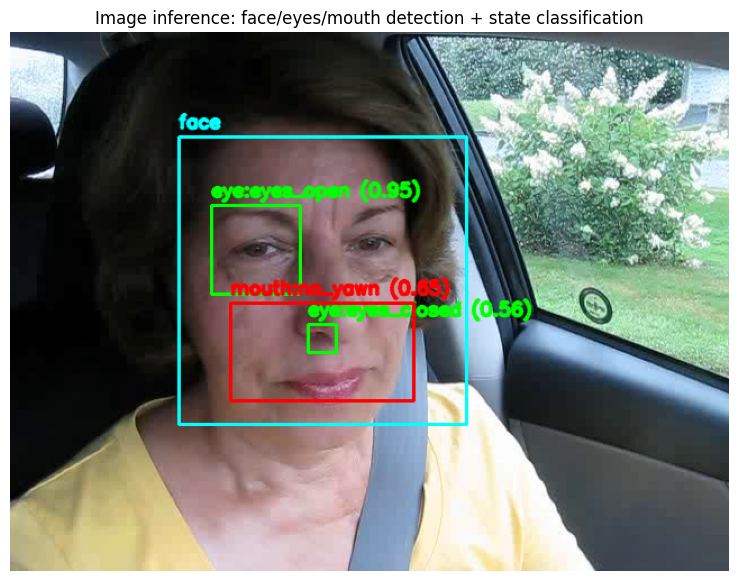

In [4]:
# IMAGE DEMO: set any local image path here and run this cell.
image_path = "train/no_yawn/2464.jpg"

image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

annotated = detect_and_annotate_states(image_bgr)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Image inference: face/eyes/mouth detection + state classification")
plt.show()

In [5]:
# WEBCAM DEMO: run this cell after image demo works.
# Press 'q' in the webcam window to quit.

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Could not open webcam. Make sure camera permissions are enabled.")

print("Webcam started. Press 'q' to quit.")
while True:
    ok, frame = cap.read()
    if not ok:
        break

    annotated = detect_and_annotate_states(frame)
    cv2.imshow("Drowsiness Demo - face/eyes/mouth", annotated)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Webcam stopped.")

Webcam started. Press 'q' to quit.
Webcam stopped.
